In [1]:
# 🧠 Mini Deep Learning Class: Gradient Descent with a Meaningful Dataset
# We'll predict Exam Scores from Hours of Study (Part A),
# then extend to include Sleep Hours (Part B).

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# Create a meaningful dataset
# -----------------------------
rng = np.random.default_rng(7)
N = 50

hours_study = rng.uniform(0, 8, size=N)        # hours studied between 0 and 8
sleep_hours = rng.uniform(4.5, 9.0, size=N)    # sleep between ~4.5 and 9 hours

# True relationship (hidden from model)
# Exam_Score = 35 + 7*Hours_Study + 2.5*Sleep_Hours + noise
true_w_study = 7.0
true_w_sleep = 2.5
true_b = 35.0

noise = rng.normal(0, 2.0, size=N)
exam_score = true_b + true_w_study * hours_study + true_w_sleep * sleep_hours + noise
exam_score = np.clip(exam_score, 0, 100)

# Show the first few rows
df = pd.DataFrame({
    "Hours_Study": hours_study,
    "Sleep_Hours": sleep_hours,
    "Exam_Score": exam_score
})
print(df.head())



   Hours_Study  Sleep_Hours  Exam_Score
0     5.000764     6.125688   81.248909
1     7.177710     7.191828  100.000000
2     6.205486     4.766632   88.555124
3     1.801658     6.244343   63.550566
4     2.401330     5.953664   71.182984


In [2]:
# ===========================================================
# 🧩 PART A: Single-input gradient descent (Hours_Study only)
# ===========================================================

x = hours_study
y = exam_score

w = 0.0
b = 0.0
lr = 0.01
epochs = 1000

loss_history = []

for epoch in range(epochs):
    y_hat = w * x + b
    residual = y_hat - y
    squared_error = residual ** 2
    loss = 0.5 * np.mean(squared_error)
    loss_history.append(loss)

    grad_w = np.mean(residual * x)
    grad_b = np.mean(residual)

    w -= lr * grad_w
    b -= lr * grad_b

    if (epoch + 1) % 200 == 0 or epoch == 0:
        print(f"[A] Epoch {epoch+1:4d} | loss={loss:.3f} | w={w:.3f} | b={b:.3f}")



[A] Epoch    1 | loss=3200.357 | w=3.463 | b=0.784
[A] Epoch  200 | loss=121.494 | w=12.338 | b=22.186
[A] Epoch  400 | loss=49.359 | w=10.122 | b=33.845
[A] Epoch  600 | loss=22.614 | w=8.772 | b=40.945
[A] Epoch  800 | loss=12.699 | w=7.951 | b=45.268
[A] Epoch 1000 | loss=9.022 | w=7.450 | b=47.900


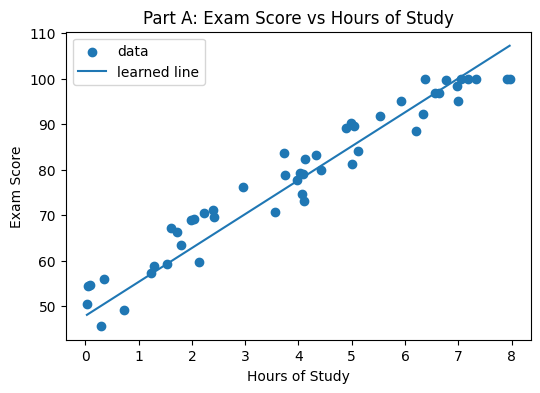

In [3]:
# Plot: data + learned line
xx = np.linspace(x.min(), x.max(), 100)
yy = w * xx + b

plt.figure(figsize=(6,4))
plt.scatter(x, y, label="data")
plt.plot(xx, yy, label="learned line")
plt.xlabel("Hours of Study")
plt.ylabel("Exam Score")
plt.title("Part A: Exam Score vs Hours of Study")
plt.legend()
plt.show()



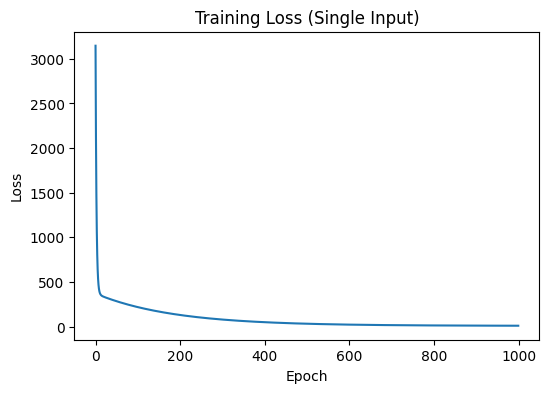

In [5]:
# Plot: loss curve
plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss (Single Input)")
plt.show()



In [6]:
# Example predictions
for hrs in [0, 2, 4, 6, 8]:
    pred = w * hrs + b
    print(f"[A] Hours_Study={hrs:>2} -> Predicted Score={pred:.1f}")



[A] Hours_Study= 0 -> Predicted Score=50.4
[A] Hours_Study= 2 -> Predicted Score=64.5
[A] Hours_Study= 4 -> Predicted Score=78.5
[A] Hours_Study= 6 -> Predicted Score=92.5
[A] Hours_Study= 8 -> Predicted Score=106.6


In [7]:
w*1000+b

np.float64(7068.82410409727)

In [63]:
# ===========================================================
# 🧩 PART B: Two-input gradient descent (Study + Sleep)
# ===========================================================

x1 = hours_study
x2 = sleep_hours
y = exam_score


In [64]:
x1_test = x1[40:]
x2_test = x2[40:]
y_test = y[40:]
x1 = x1[:40]
x2 = x2[:40]
y = y[:40]

In [23]:
x1.shape, x2.shape, y.shape, x1_test.shape, x2_test.shape, y_test.shape

((40,), (40,), (40,), (10,), (10,), (10,))

In [24]:

w1, w2, b = 0.0, 0.0, 0.0
lr = 0.03
epochs = 2000
loss_history_B = []

for epoch in range(epochs):
    y_hat = w1 * x1 + w2 * x2 + b
    residual = y_hat - y
    loss = 0.5 * np.mean(residual ** 2)
    loss_history_B.append(loss)

    grad_w1 = np.mean(residual * x1)
    grad_w2 = np.mean(residual * x2)
    grad_b  = np.mean(residual)

    w1 -= lr * grad_w1
    w2 -= lr * grad_w2
    b  -= lr * grad_b

    if (epoch + 1) % 200 == 0 or epoch == 0:
        print(f"[B] Epoch {epoch+1:4d} | loss={loss:.3f} | w1={w1:.3f} | w2={w2:.3f} | b={b:.3f}")



[B] Epoch    1 | loss=3098.374 | w1=9.778 | w2=15.739 | b=2.314
[B] Epoch  200 | loss=19.945 | w1=7.060 | w2=6.326 | b=6.894
[B] Epoch  400 | loss=15.916 | w1=6.950 | w2=5.689 | b=11.759
[B] Epoch  600 | loss=13.085 | w1=6.858 | w2=5.155 | b=15.836
[B] Epoch  800 | loss=11.096 | w1=6.781 | w2=4.707 | b=19.253
[B] Epoch 1000 | loss=9.699 | w1=6.716 | w2=4.332 | b=22.118
[B] Epoch 1200 | loss=8.718 | w1=6.662 | w2=4.018 | b=24.518
[B] Epoch 1400 | loss=8.028 | w1=6.616 | w2=3.754 | b=26.531
[B] Epoch 1600 | loss=7.544 | w1=6.578 | w2=3.533 | b=28.217
[B] Epoch 1800 | loss=7.204 | w1=6.546 | w2=3.348 | b=29.631
[B] Epoch 2000 | loss=6.965 | w1=6.519 | w2=3.193 | b=30.816


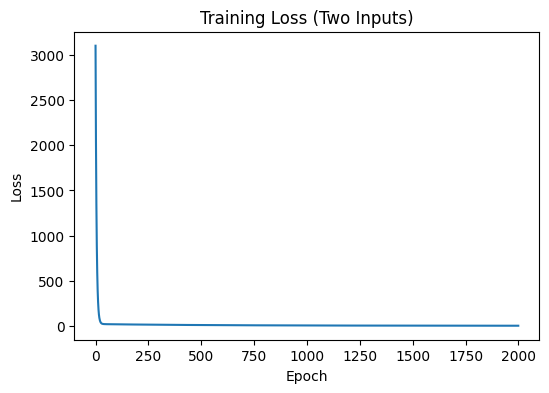

In [25]:
# Plot loss for two-input model
plt.figure(figsize=(6,4))
plt.plot(loss_history_B)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss (Two Inputs)")
plt.show()


In [26]:
# Predictions with two inputs
examples = [(2, 6.5), (4, 7.0), (6, 6.0), (8, 7.5)]
for hrs, slp in examples:
    pred = w1 * hrs + w2 * slp + b
    print(f"[B] Study={hrs:>2}h, Sleep={slp:.1f}h -> Predicted Score={pred:.1f}")

print("\nTrue parameters:")
print(f"w_study={true_w_study:.2f}, w_sleep={true_w_sleep:.2f}, b={true_b:.2f}")
print("Learned parameters:")
print(f"w1={w1:.2f}, w2={w2:.2f}, b={b:.2f}")


[B] Study= 2h, Sleep=6.5h -> Predicted Score=64.6
[B] Study= 4h, Sleep=7.0h -> Predicted Score=79.2
[B] Study= 6h, Sleep=6.0h -> Predicted Score=89.1
[B] Study= 8h, Sleep=7.5h -> Predicted Score=106.9

True parameters:
w_study=7.00, w_sleep=2.50, b=35.00
Learned parameters:
w1=6.52, w2=3.19, b=30.82


In [27]:
y_test_hat = w1*x1_test + w2*x2_test + b

In [32]:
y_test_hat, y_test

(array([ 59.68807251, 103.68824964,  78.49335412,  97.23628178,
         83.17794965,  94.6670844 ,  50.31869868,  78.755676  ,
         72.10340802,  92.39476019]),
 array([ 57.76309624, 100.        ,  77.88868256,  99.64654814,
         82.52531297,  93.737286  ,  46.54631807,  85.76941557,
         74.41033575, 100.        ]))

In [34]:
0.5*np.mean((y_test_hat - y_test)**2)

np.float64(7.567958830991396)

# Training with activation function

In [39]:
def relu(x):
    return np.array([max(x[i], 0) for i in range(len(x))])

In [ ]:

w1, w2, b = 0.0, 0.0, 0.0
lr = 0.03
epochs = 2000
loss_history_B = []

for epoch in range(epochs):
    y_hat = relu(w1 * x1 + w2 * x2 + b)
    residual = y_hat - y
    loss = 0.5 * np.mean(residual ** 2)
    loss_history_B.append(loss)

    grad_w1 = np.mean(residual * x1)
    grad_w2 = np.mean(residual * x2)
    grad_b  = np.mean(residual)

    w1 -= lr * grad_w1
    w2 -= lr * grad_w2
    b  -= lr * grad_b

    if (epoch + 1) % 200 == 0 or epoch == 0:
        print(f"[B] Epoch {epoch+1:4d} | loss={loss:.3f} | w1={w1:.3f} | w2={w2:.3f} | b={b:.3f}")



[B] Epoch    1 | loss=3200.357 | w1=10.389 | w2=15.738 | b=2.352
[B] Epoch  200 | loss=16.808 | w1=7.212 | w2=6.232 | b=7.573
[B] Epoch  400 | loss=12.021 | w1=7.101 | w2=5.525 | b=12.871
[B] Epoch  600 | loss=8.814 | w1=7.011 | w2=4.947 | b=17.207
[B] Epoch  800 | loss=6.666 | w1=6.938 | w2=4.473 | b=20.756
[B] Epoch 1000 | loss=5.227 | w1=6.877 | w2=4.086 | b=23.661
[B] Epoch 1200 | loss=4.264 | w1=6.828 | w2=3.769 | b=26.039
[B] Epoch 1400 | loss=3.618 | w1=6.787 | w2=3.509 | b=27.985
[B] Epoch 1600 | loss=3.185 | w1=6.754 | w2=3.297 | b=29.577
[B] Epoch 1800 | loss=2.896 | w1=6.727 | w2=3.123 | b=30.881
[B] Epoch 2000 | loss=2.702 | w1=6.705 | w2=2.980 | b=31.948


# Stochastic gradient descent

In [49]:

w1, w2, b = 0.0, 0.0, 0.0
lr = 0.03
epochs = 2000
loss_history_B = []

for epoch in range(epochs):
    for row in range(len(x1)):
        y_hat = w1 * x1[row] + w2 * x2[row] + b
        residual = y_hat - y[row]
        loss = 0.5 * np.mean(residual ** 2)
        loss_history_B.append(loss)

        grad_w1 = np.mean(residual * x1[row])
        grad_w2 = np.mean(residual * x2[row])
        grad_b  = np.mean(residual)

        w1 -= lr * grad_w1
        w2 -= lr * grad_w2
        b  -= lr * grad_b

    if (epoch + 1) % 200 == 0 or epoch == 0:
        print(f"[B] Epoch {epoch+1:4d} | loss={loss:.3f} | w1={w1:.3f} | w2={w2:.3f} | b={b:.3f}")



[B] Epoch    1 | loss=529.932 | w1=4.701 | w2=19.734 | b=6.693
[B] Epoch  200 | loss=7.358 | w1=7.804 | w2=2.055 | b=38.387
[B] Epoch  400 | loss=7.358 | w1=7.804 | w2=2.055 | b=38.387
[B] Epoch  600 | loss=7.358 | w1=7.804 | w2=2.055 | b=38.387
[B] Epoch  800 | loss=7.358 | w1=7.804 | w2=2.055 | b=38.387
[B] Epoch 1000 | loss=7.358 | w1=7.804 | w2=2.055 | b=38.387
[B] Epoch 1200 | loss=7.358 | w1=7.804 | w2=2.055 | b=38.387
[B] Epoch 1400 | loss=7.358 | w1=7.804 | w2=2.055 | b=38.387
[B] Epoch 1600 | loss=7.358 | w1=7.804 | w2=2.055 | b=38.387
[B] Epoch 1800 | loss=7.358 | w1=7.804 | w2=2.055 | b=38.387
[B] Epoch 2000 | loss=7.358 | w1=7.804 | w2=2.055 | b=38.387


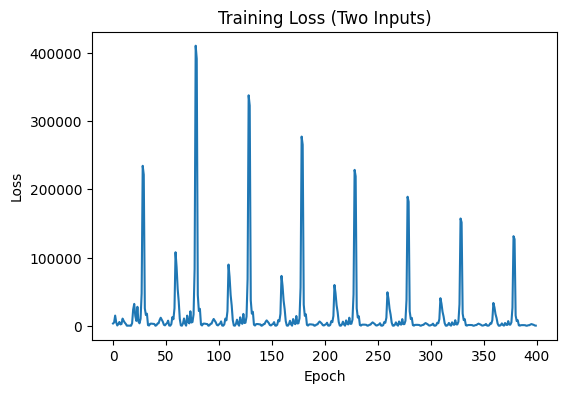

In [51]:
# Plot loss for two-input model
plt.figure(figsize=(6,4))
plt.plot(loss_history_B[:400])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss (Two Inputs)")
plt.show()


# Mini-Batch Gradient Descent

In [68]:

w1, w2, b = 0.0, 0.0, 0.0
lr = 0.03
epochs = 2000
loss_history_B = []
batch_size = 17

for epoch in range(epochs):
    for row in range(0,len(x1),batch_size):
        y_hat = w1 * x1[row:row + batch_size] + w2 * x2[row:row + batch_size] + b
        residual = y_hat - y[row:row + batch_size]
        loss = 0.5 * np.mean(residual ** 2)
        loss_history_B.append(loss)

        grad_w1 = np.mean(residual * x1[row:row + batch_size])
        grad_w2 = np.mean(residual * x2[row:row + batch_size])
        grad_b  = np.mean(residual)

        w1 -= lr * grad_w1
        w2 -= lr * grad_w2
        b  -= lr * grad_b

    if (epoch + 1) % 200 == 0 or epoch == 0:
        print(f"[B] Epoch {epoch+1:4d} | loss={loss:.3f} | w1={w1:.3f} | w2={w2:.3f} | b={b:.3f}")



[B] Epoch    1 | loss=2650.243 | w1=9.660 | w2=14.104 | b=2.299
[B] Epoch  200 | loss=8.728 | w1=6.808 | w2=5.715 | b=14.976
[B] Epoch  400 | loss=4.611 | w1=6.706 | w2=4.508 | b=23.295
[B] Epoch  600 | loss=3.021 | w1=6.644 | w2=3.777 | b=28.336
[B] Epoch  800 | loss=2.388 | w1=6.606 | w2=3.334 | b=31.391
[B] Epoch 1000 | loss=2.127 | w1=6.583 | w2=3.065 | b=33.242
[B] Epoch 1200 | loss=2.013 | w1=6.570 | w2=2.902 | b=34.363
[B] Epoch 1400 | loss=1.961 | w1=6.561 | w2=2.804 | b=35.043
[B] Epoch 1600 | loss=1.935 | w1=6.556 | w2=2.744 | b=35.455
[B] Epoch 1800 | loss=1.922 | w1=6.553 | w2=2.708 | b=35.705
[B] Epoch 2000 | loss=1.914 | w1=6.551 | w2=2.686 | b=35.856


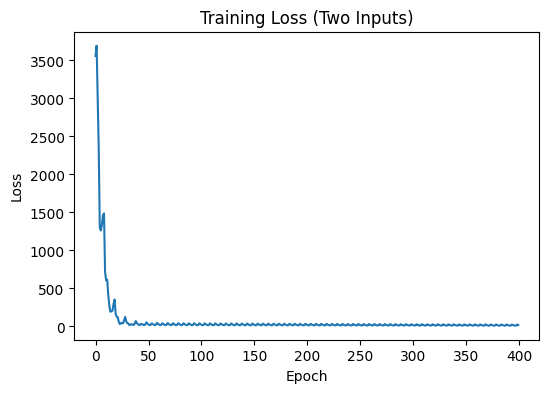

In [56]:
# Plot loss for two-input model
plt.figure(figsize=(6,4))
plt.plot(loss_history_B[:400])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss (Two Inputs)")
plt.show()


In [69]:
y_test_hat = w1*x1_test + w2*x2_test + b

In [70]:
y_test_hat, y_test

(array([ 62.42667735, 104.66974631,  80.3128744 ,  98.9593676 ,
         85.3628555 ,  95.89836487,  53.04178713,  80.80128169,
         74.92080288,  95.09355292]),
 array([ 59.71340089, 100.        ,  78.97446643,  99.74892896,
         84.11190578,  94.9894322 ,  49.10176838,  83.25527694,
         74.7185109 ,  98.35938448]))

# More Neurons!

In [ ]:
for epoch in range(epochs):
    y_hat1 = w1 * x1 + w2 * x2 + b1
    y_hat2 = w3 * x1 + w4 * x2 + b2
    final_prediction = w5*y_hat1 + w6*y_hat2 + b3

    